# Network Analysis Sandbox
This notebook loads the stock similarity matrix and builds a network using the logic from `main.py`. Use the cells below to explore the graph structure and run custom analysis.

In [2]:
import sys
import os
import networkx as nx
import pandas as pd
from pathlib import Path

# Add project root to sys.path to allow importing main.py
sys.path.append(os.path.abspath('.'))

# Import the existing build_network function
from main import build_network

# Configuration
output_dir = Path("output")
similarity_file = output_dir / "ticker_similarities.csv"

# Load and process the similarity matrix
if not similarity_file.exists():
    print(f"Error: {similarity_file} not found. Please run data_processor.py first.")
else:
    # Load the similarity matrix
    sim_df = pd.read_csv(similarity_file, index_col=0)

    # Calculate simple cosine distance: d = 1 - s
    cosine_dist = 1.0 - sim_df.values
    dist_df = pd.DataFrame(cosine_dist, index=sim_df.index, columns=sim_df.columns)

    # Build the network using the shared logic
    G = build_network(dist_df)
    print(f"Graph loaded with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Building a dense graph from distance matrix...
Graph built with 2443 nodes and 2982903 edges.
Graph loaded with 2443 nodes and 2982903 edges.


### Basic Visualization and Top Closest Pairs
Identify the stocks that have the lowest cosine distance (and thus highest similarity).

In [3]:
# Display Top 10 Closest Ticker Pairs
print("\nTop 10 Closest Ticker Pairs (by Cosine Distance):")
edges = sorted(G.edges(data=True), key=lambda x: x[2].get("weight", 1.0))

count = 0
for u, v, d in edges:
    if count >= 10:
        break
    print(f"{u} <-> {v}: distance = {d['weight']:.4f}")
    count += 1

count = 0
for u, v, d in edges:
    if count >= 10:
        break
    print(f"{u} <-> {v}: distance = {d['weight']:.4f}")
    count += 1



Top 10 Closest Ticker Pairs (by Cosine Distance):
GOOG <-> GOOGL: distance = 0.0001
LILA <-> LILAK: distance = 0.0035
LBRDA <-> LBRDK: distance = 0.0039
CCL <-> CUK: distance = 0.0048
Z <-> ZG: distance = 0.0052
LBTYA <-> LBTYK: distance = 0.0063
FOX <-> FOXA: distance = 0.0075
UA <-> UAA: distance = 0.0099
NWS <-> NWSA: distance = 0.0114
CENT <-> CENTA: distance = 0.0196
GOOG <-> GOOGL: distance = 0.0001
LILA <-> LILAK: distance = 0.0035
LBRDA <-> LBRDK: distance = 0.0039
CCL <-> CUK: distance = 0.0048
Z <-> ZG: distance = 0.0052
LBTYA <-> LBTYK: distance = 0.0063
FOX <-> FOXA: distance = 0.0075
UA <-> UAA: distance = 0.0099
NWS <-> NWSA: distance = 0.0114
CENT <-> CENTA: distance = 0.0196


In [4]:
# Calculate hubs in the Minimum Spanning Tree (MST)
# T is the MST calculated in the previous cell
T = nx.minimum_spanning_tree(G, weight="weight")

# Get degrees for all nodes in the MST
mst_degrees = dict(T.degree())

# Sort nodes by degree in descending order
top_mst_hubs = sorted(mst_degrees.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Hub Nodes in the MST (Highest Degree):")
for node, degree in top_mst_hubs:
    print(f"{node}: degree = {degree}")

# Optional: Highlight these hubs in a printout of their neighbors
print("\nConnections for the top MST hub:")
top_hub = top_mst_hubs[0][0]
neighbors = list(T.neighbors(top_hub))
print(f"{top_hub} is connected to: {', '.join(neighbors)}")


Top 5 Hub Nodes in the MST (Highest Degree):
ITT: degree = 26
CSQ: degree = 25
HAL: degree = 18
MCO: degree = 17
FCF: degree = 16

Connections for the top MST hub:
ITT is connected to: PH, DOV, TEL, ETN, FSS, DCI, KMT, LECO, TKR, CRH, OC, FUL, WTS, NPO, SPXC, MIDD, JCI, AXTA, SNA, ESE, CX, GTES, AYI, LKQ, TTC, RMR


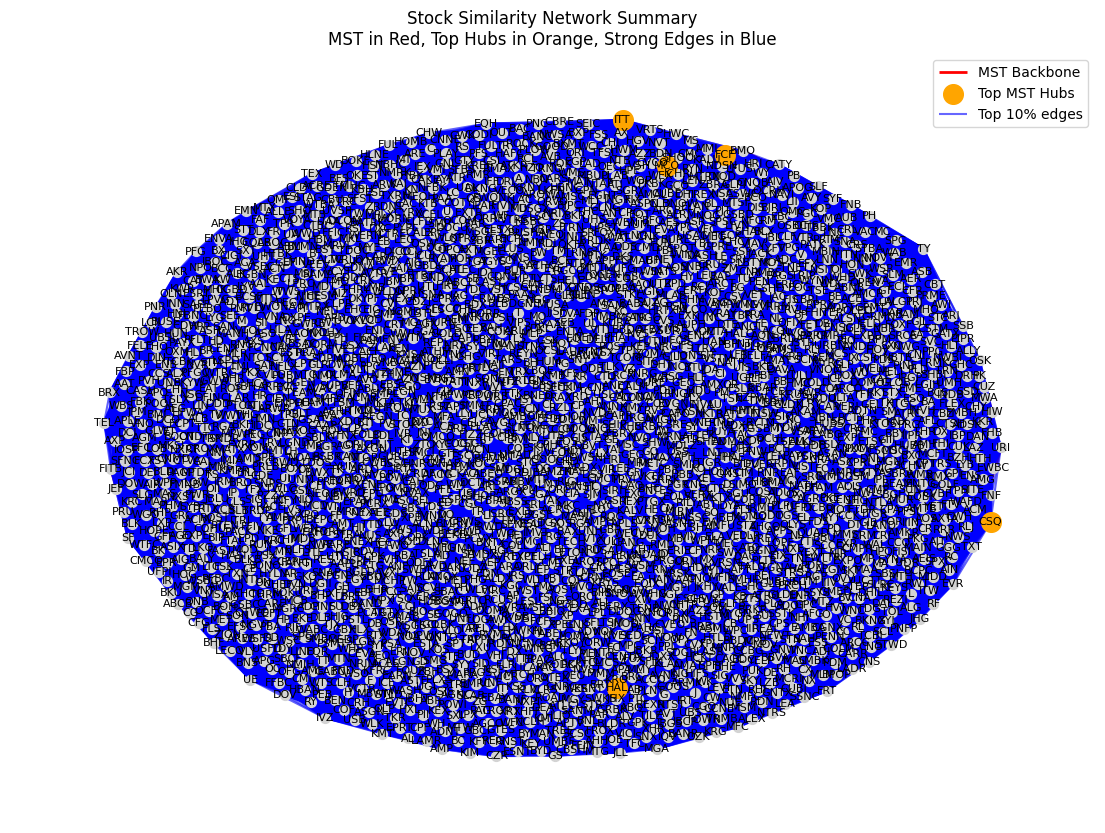

In [6]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# --- 1. Calculate MST ---
T = nx.minimum_spanning_tree(G, weight="weight")

# --- 2. Identify top hubs by degree in the MST ---
mst_degrees = dict(T.degree())
top_mst_hubs = sorted(mst_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
top_hub_nodes = [node for node, _ in top_mst_hubs]

# --- 3. Position nodes with force-directed layout ---
pos = nx.spring_layout(G, seed=42)

# --- 4. Draw the full network lightly ---
plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='lightgray')
nx.draw_networkx_edges(G, pos, edge_color='lightgray', alpha=0.3)

# --- 5. Highlight MST edges ---
nx.draw_networkx_edges(T, pos, edge_color='red', width=2, label='MST Backbone')

# --- 6. Highlight top hubs ---
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=top_hub_nodes,
    node_size=200,
    node_color='orange',
    label='Top MST Hubs'
)

# --- 7. Highlight strongest edges (top 10% by weight) ---
edges = G.edges(data=True)
# Higher similarity = smaller distance, so strongest edges = smallest weight
weights = [d['weight'] for _, _, d in edges]
threshold = np.percentile(weights, 10)  # top 10% strongest
strong_edges = [(u, v) for u, v, d in edges if d['weight'] <= threshold]
nx.draw_networkx_edges(G, pos, edgelist=strong_edges, width=1.5, edge_color='blue', alpha=0.6, label='Top 10% edges')

# --- 8. Labels ---
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Stock Similarity Network Summary\nMST in Red, Top Hubs in Orange, Strong Edges in Blue")
plt.axis('off')
plt.legend(scatterpoints=1)
plt.show()